In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

import matplotlib as mpl
import emcee
import corner
from getdist import MCSamples, plots
import scipy

In [2]:
mpl.rcParams['font.size'] = 12  # Taille générale
mpl.rcParams['axes.titlesize'] = 16  # Taille des titres des graphiques
mpl.rcParams['axes.labelsize'] = 14  # Taille des labels des axes
mpl.rcParams['xtick.labelsize'] = 12  # Taille des étiquettes de l'axe x
mpl.rcParams['ytick.labelsize'] = 12  # Taille des étiquettes de l'axe y
mpl.rcParams['legend.fontsize'] = 12  # Taille de la légende
mpl.rcParams['figure.titlesize'] = 18  # Taille du titre de la figure

In [3]:
galaxy1="NGC5128_CenA"
galaxy2="NGC5236_M83"
r=0.76
CoM_Name="CoM_CenA_M83_0.76"
row_name=CoM_Name


In [4]:
file_path = '../../data/generated_data_small.csv'
galaxy_df = pd.read_csv(file_path)

In [5]:
df=galaxy_df
mask = ~df['Name'].str.startswith('CoM_')
G = 4.3009e-9  # Constante gravitationnelle en (km/s)² Mpc / M☉

# Minor Infall

In [6]:
def velocity_model_1(r, H0, M ,derivative=False):
    Omega_Lambda = 0.67

    # Avoid numerical issues with the square root
    if M <= 0:
        return np.full_like(r, np.nan)  # avoid sqrt of negative mass
    
    term1 = H0 * (1.1 + 0.31 * Omega_Lambda) * r
    
    # Check if the term inside sqrt will be negative
    sqrt_term = G * M / r
    valid_points = sqrt_term > 0
    
    result = np.full_like(r, np.nan)
    if np.any(valid_points):
        result[valid_points] = term1[valid_points] - 1.1 * np.sqrt(sqrt_term[valid_points])
    if not derivative:    
        return result
    else:
        result_derivative = np.full_like(r, np.nan)
        result_derivative[valid_points] = H0 * (1.1 + 0.31 * Omega_Lambda) + (1.1/2) * np.sqrt(sqrt_term[valid_points]) / r[valid_points]
        return (result,result_derivative)


In [ ]:
def analyze_velocity_model(df, mask,velocity, row_name,velocity_model, xmin=1,xmax=15,plot=True):
    # -------------------
    # 1. Data preparation
    # -------------------
    df_clean = df.loc[mask, [
        'dis_center_' + row_name,
        velocity + '_' + row_name,
        'e_dis_center_min_' + row_name,
        'e_dis_center_max_' + row_name,
        'e_'+velocity+'_min_' + row_name,
        'e_'+velocity+'_max_' + row_name
    ]].apply(pd.to_numeric, errors='coerce').dropna()

    x = df_clean['dis_center_' + row_name].values
    y = df_clean[velocity+'_' + row_name].values

    xerr_low_full = df_clean['e_dis_center_min_' + row_name].values
    xerr_high_full = df_clean['e_dis_center_max_' + row_name].values
    yerr_low_full = df_clean['e_'+velocity+'_min_' + row_name].values
    yerr_high_full = df_clean['e_'+velocity+'_max_' + row_name].values

    # Apply the (0.5 <= x <= 5) mask uniformly
    mask_fit = (x >= xmin) & (x <= xmax)
    x = x[mask_fit]
    y = y[mask_fit]
    xerr_low = xerr_low_full[mask_fit]
    xerr_high = xerr_high_full[mask_fit]
    yerr_low = yerr_low_full[mask_fit]
    yerr_high = yerr_high_full[mask_fit]
    
    # Calculate symmetrized errors for MCMC (missing in original)
    xerr_sym = (xerr_low + xerr_high) / 2
    yerr_sym = (yerr_low + yerr_high) / 2

    # -------------------
    # 2. Define the model
    # -------------------

    # -------------------
    # 3. Log-likelihood
    # -------------------
    def total_velocity_error(r, v_err, r_err, H0, M):
        # Calculate the derivative df/dx numerically
        dr = 1e-5 * r  # small relative step
        f_plus = velocity_model(r + dr, H0, M)
        f_minus = velocity_model(r - dr, H0, M)
        df_dx = (f_plus - f_minus) / (2 * dr)

        # Now compute total error
        return np.sqrt(v_err**2 + (df_dx * r_err)**2)

    def log_likelihood(theta, r, r_err, v, v_err):
        H0, M = theta
        model = velocity_model(r, H0, M)
        if not np.all(np.isfinite(model)):
            return -np.inf
    
        # Total error including propagated uncertainty from r
        v_total_err = total_velocity_error(r, v_err, r_err, H0, M)
        if not np.all(np.isfinite(v_total_err)) or np.any(v_total_err == 0):
            return -np.inf
    
        return -0.5 * np.sum(((v - model) / v_total_err)**2  + np.log(2 * np.pi * v_total_err**2))

    def log_prior(theta,H0_prior=False,M_prior=False):
        H0, M = theta
        if H0_prior:
            if 1e11 < M < 1e14:
                logp_H0 = -0.5 * ((H0 - 73) / 1.0)**2 - np.log(np.sqrt(2 * np.pi) * 1.0)
                return logp_H0
            return -np.inf
        
        elif M_prior:
            
            if 30 < H0 < 90 and M > 0:
                # Gaussian prior on M: mean=3e12, sigma=1e12
                logp_M = -0.5 * ((M - 3e12) / 1e12)**2 - np.log(np.sqrt(2 * np.pi) * 1e12)
                return logp_M
        else:
            if 30 < H0 < 150 and 1e11 < M < 1e14:
                return 0.0  # flat prior
            return -np.inf  # log(0)
        return -np.inf

    def log_probability(theta, r, r_err, v, v_err):
        lp = log_prior(theta)
        if not np.isfinite(lp):
            return -np.inf
        return lp + log_likelihood(theta, r, r_err, v, v_err)

    # -------------------
    # 4. Run MCMC
    # -------------------
    ndim = 2
    nwalkers = 32
    p0 = np.array([70, 1e12]) + 2e-4 * np.random.randn(nwalkers, ndim)

    sampler_min = emcee.EnsembleSampler(nwalkers, ndim, log_probability, 
                                     args=(x, xerr_sym, y, yerr_sym))
    sampler_min.run_mcmc(p0, 5000, progress=True)

    # Get the flat samples (renamed from the original)
    samples_min = sampler_min.get_chain(discard=1000, thin=15, flat=True)

    # -------------------
    # 5. Use GetDist for posterior plots
    # -------------------
    if plot:
        names = ['H0', 'M']
        labels = [r'H_0', r'M \,[kg]']  # LaTeX labels

        # Create MCSamples object from your MCMC samples
        gdsamples_min = MCSamples(samples=samples_min, names=names, labels=labels)

        # Create the triangle plot
        g = plots.get_subplot_plotter()
        g.triangle_plot(gdsamples_min, filled=True)
        plt.show()

        # -------------------
        # 6. Plot best-fit model
        # -------------------
        H0_mcmc, M_mcmc = np.median(samples_min, axis=0)


        H0_lower, M_lower = np.percentile(samples_min, 16, axis=0)
        H0_upper, M_upper = np.percentile(samples_min, 84, axis=0)

        # Compute uncertainties
        H0_uncertainty = 0.5 * (H0_upper - H0_lower)
        M_uncertainty = 0.5 * (M_upper - M_lower)

        # Fine grid
        r_plot = np.linspace(xmin, 15, 500)
        v_median = velocity_model(r_plot, H0_mcmc, M_mcmc)

        # Sample 100 posterior draws to make uncertainty band
        v_samples_min = np.array([velocity_model(r_plot, h0, m) for h0, m in samples_min[np.random.choice(len(samples_min), 1000, replace=False)]])

        v_lower = np.percentile(v_samples_min, 0.15, axis=0)
        v_upper = np.percentile(v_samples_min, 99.15, axis=0)

        # Plot
        fig, ax = plt.subplots(figsize=(10, 8))
        ax.errorbar(x, y, xerr=[xerr_low, xerr_high], yerr=[yerr_low, yerr_high],
                    fmt='o', color='black', ecolor='red', capsize=5, label='Data')

        ax.plot(r_plot, v_median, 'r-', color='blue',label=(rf"Fit: $H_0 = {H0_mcmc:.1f} \pm {H0_uncertainty:.1f}$"+ "\n"+ rf"$M = ({M_mcmc/1e12:.2f} \pm {M_uncertainty/1e12:.2f}) \times 10^{{12}}\, M_\odot$"))
        ax.fill_between(r_plot, v_lower, v_upper, color='blue', alpha=0.3, label=rf"$3\sigma$ credible interval")

        ax.set_xlabel("Distance from CoM (Mpc)")
        ax.set_ylabel(r"$v{r}$ (km/s)")
        ax.grid(True)
        ax.set_xlim(0, 15)
        ax.set_ylim(-300, 1000)
        ax.legend()
        plt.plot()
        return H0_mcmc, H0_uncertainty, M_mcmc, M_uncertainty, samples_min
    else:
        H0_mcmc, M_mcmc = np.median(samples_min, axis=0)
        H0_lower, M_lower = np.percentile(samples_min, 16, axis=0)
        H0_upper, M_upper = np.percentile(samples_min, 84, axis=0)
        H0_uncertainty = 0.5 * (H0_upper - H0_lower)
        M_uncertainty = 0.5 * (M_upper - M_lower)
        return H0_mcmc, H0_uncertainty, M_mcmc, M_uncertainty, samples_min

100%|██████████| 5000/5000 [00:17<00:00, 292.92it/s]


Removed no burn in


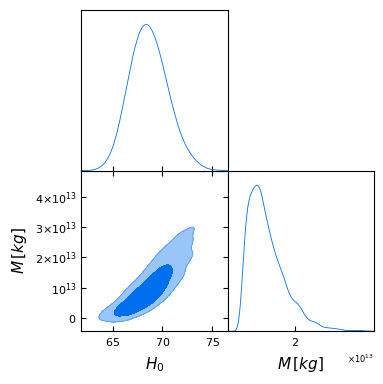

C:\Users\Adrian\AppData\Local\Temp\ipykernel_13684\2484682099.py:11: RuntimeWarning: divide by zero encountered in divide
  sqrt_term = G * M / r
C:\Users\Adrian\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\Adrian\AppData\Local\Temp\ipykernel_13684\3599314567.py:171: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(r_plot, v_median, 'r-', color='blue',label=(rf"Fit: $H_0 = {H0_mcmc:.1f} \pm {H0_uncertainty:.1f}$"+ "\n"+ rf"$M = ({M_mcmc/1e12:.2f} \pm {M_uncertainty/1e12:.2f}) \times 10^{{12}}\, M_\odot$"))
100%|██████████| 5000/5000 [00:16<00:00, 296.12it/s]


Removed no burn in


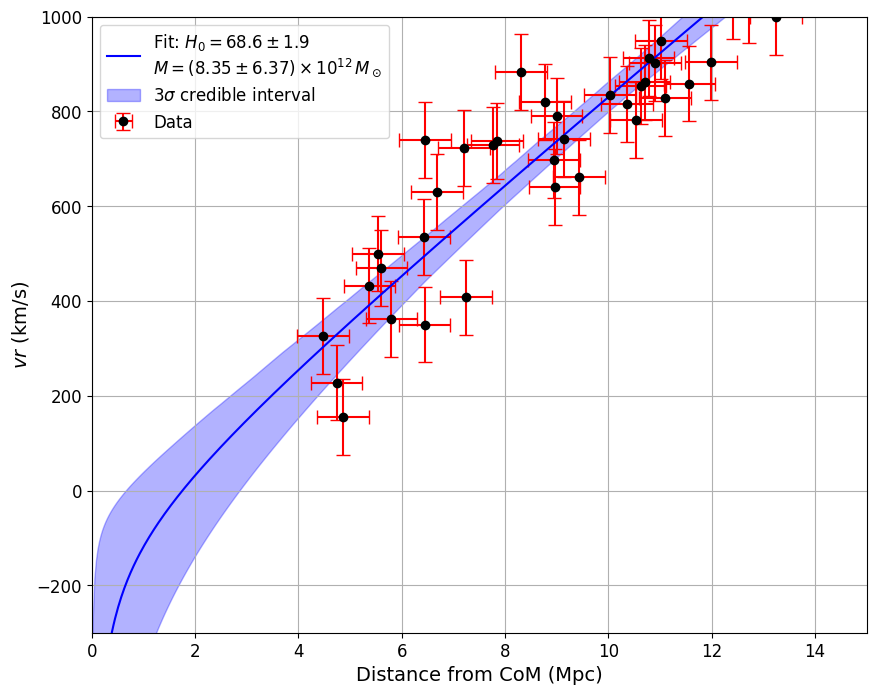

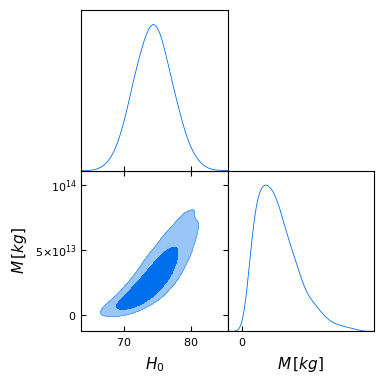

C:\Users\Adrian\AppData\Local\Temp\ipykernel_13684\2484682099.py:11: RuntimeWarning: divide by zero encountered in divide
  sqrt_term = G * M / r
C:\Users\Adrian\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\Adrian\AppData\Local\Temp\ipykernel_13684\3599314567.py:171: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(r_plot, v_median, 'r-', color='blue',label=(rf"Fit: $H_0 = {H0_mcmc:.1f} \pm {H0_uncertainty:.1f}$"+ "\n"+ rf"$M = ({M_mcmc/1e12:.2f} \pm {M_uncertainty/1e12:.2f}) \times 10^{{12}}\, M_\odot$"))


Removed no burn in
Removed no burn in


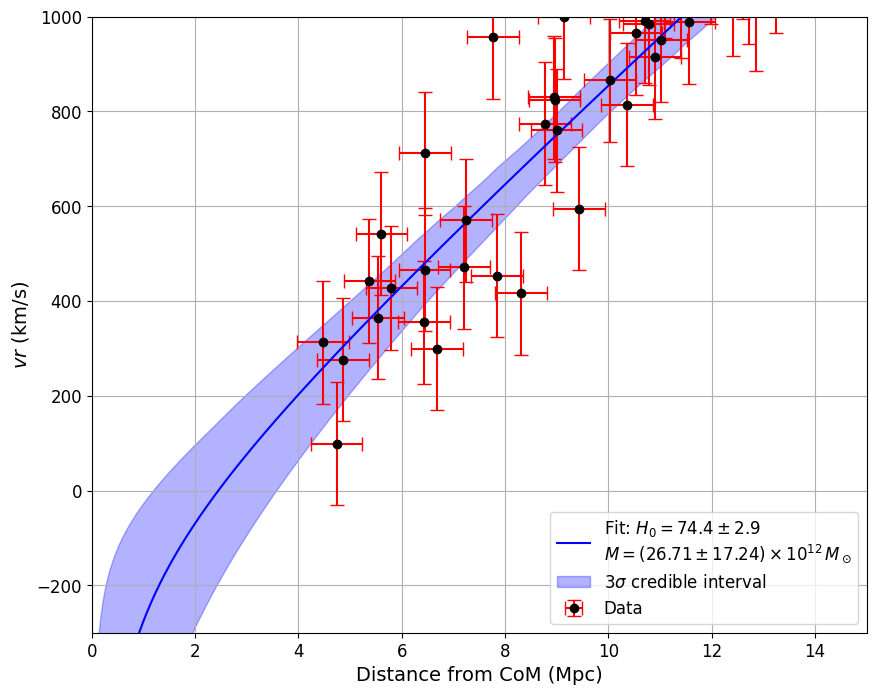

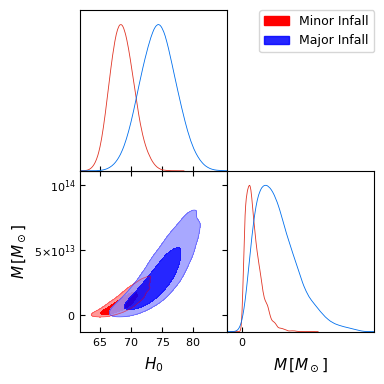

=== Résultats Minor Infall ===
H0 = 68.55 ± 1.93
M = (8.35 ± 6.37) × 10^12 M_☉

=== Résultats Major Infall ===
H0 = 74.37 ± 2.92
M = (26.71 ± 17.24) × 10^12 M_☉


In [8]:
H0_min, H0_sigma_min, M_min, M_sigma_min, samples_min = analyze_velocity_model(df=df, mask= mask,row_name= row_name,velocity='minor_infall_velocity',velocity_model=velocity_model_1, xmin=0, xmax=300)
H0_maj, H0_sigma_maj, M_maj, M_sigma_maj, samples_maj = analyze_velocity_model(df=df, mask= mask,row_name= row_name,velocity='major_infall_velocity',velocity_model=velocity_model_1, xmin=0, xmax=300)

# Définition des noms et labels cohérents
names = ['H0', 'M']
labels = [r'H_0', r'M \,[M_\odot]']  # Utiliser M_☉ (masse solaire) pour être cohérent

# Créer les objets MCSamples pour les deux analyses
gdsamples_min = MCSamples(samples=samples_min, names=names, labels=labels)
gdsamples_maj = MCSamples(samples=samples_maj, names=names, labels=labels)

# Créer le triangle plot avec les deux distributions
g = plots.get_subplot_plotter()
g.triangle_plot([gdsamples_min, gdsamples_maj], 
                filled=True, 
                legend_labels=['Minor Infall', 'Major Infall'],
                colors=['red', 'blue'])  # Ajouter des couleurs différentes pour mieux distinguer

plt.show()

# Optionnel : afficher les résultats numériques
print("=== Résultats Minor Infall ===")
print(f"H0 = {H0_min:.2f} ± {H0_sigma_min:.2f}")
print(f"M = ({M_min/1e12:.2f} ± {M_sigma_min/1e12:.2f}) × 10^12 M_☉")

print("\n=== Résultats Major Infall ===")
print(f"H0 = {H0_maj:.2f} ± {H0_sigma_maj:.2f}")
print(f"M = ({M_maj/1e12:.2f} ± {M_sigma_maj/1e12:.2f}) × 10^12 M_☉")

In [11]:
file_path = '../../data/generated_data_medium.csv'
galaxy_df = pd.read_csv(file_path)
mask = ~galaxy_df['Name'].str.startswith('CoM_')

  0%|          | 0/5000 [00:00<?, ?it/s]

100%|██████████| 5000/5000 [00:18<00:00, 265.17it/s]


Removed no burn in


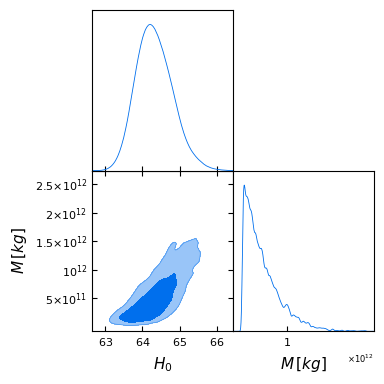

C:\Users\Adrian\AppData\Local\Temp\ipykernel_13684\2484682099.py:11: RuntimeWarning: divide by zero encountered in divide
  sqrt_term = G * M / r
C:\Users\Adrian\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\Adrian\AppData\Local\Temp\ipykernel_13684\3599314567.py:171: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(r_plot, v_median, 'r-', color='blue',label=(rf"Fit: $H_0 = {H0_mcmc:.1f} \pm {H0_uncertainty:.1f}$"+ "\n"+ rf"$M = ({M_mcmc/1e12:.2f} \pm {M_uncertainty/1e12:.2f}) \times 10^{{12}}\, M_\odot$"))
100%|██████████| 5000/5000 [00:22<00:00, 226.40it/s]


Removed no burn in


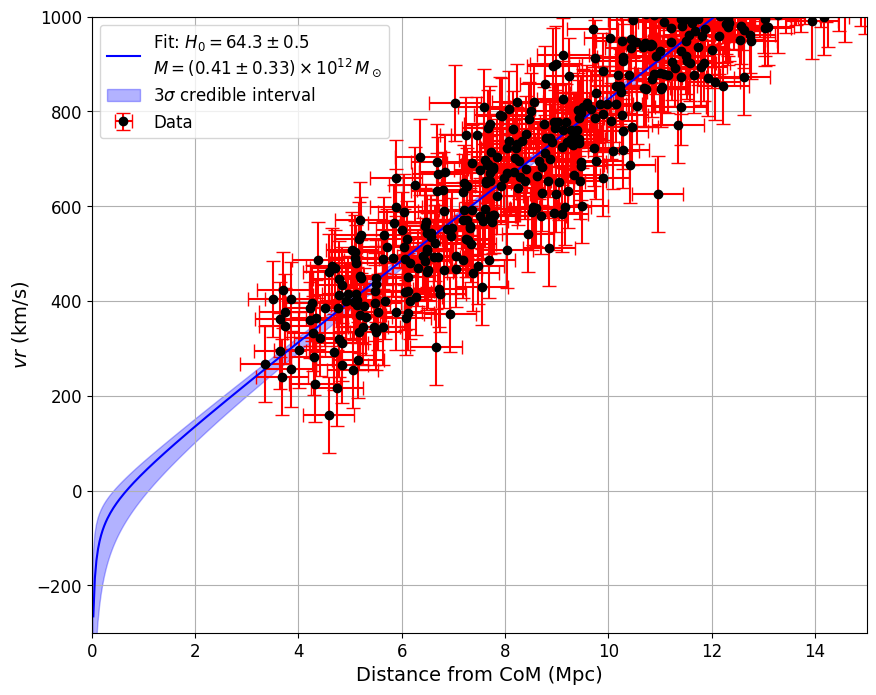

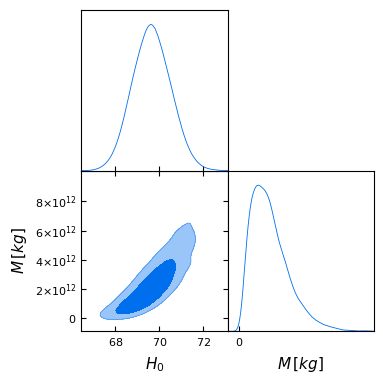

C:\Users\Adrian\AppData\Local\Temp\ipykernel_13684\2484682099.py:11: RuntimeWarning: divide by zero encountered in divide
  sqrt_term = G * M / r
C:\Users\Adrian\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\Adrian\AppData\Local\Temp\ipykernel_13684\3599314567.py:171: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(r_plot, v_median, 'r-', color='blue',label=(rf"Fit: $H_0 = {H0_mcmc:.1f} \pm {H0_uncertainty:.1f}$"+ "\n"+ rf"$M = ({M_mcmc/1e12:.2f} \pm {M_uncertainty/1e12:.2f}) \times 10^{{12}}\, M_\odot$"))


Removed no burn in
Removed no burn in


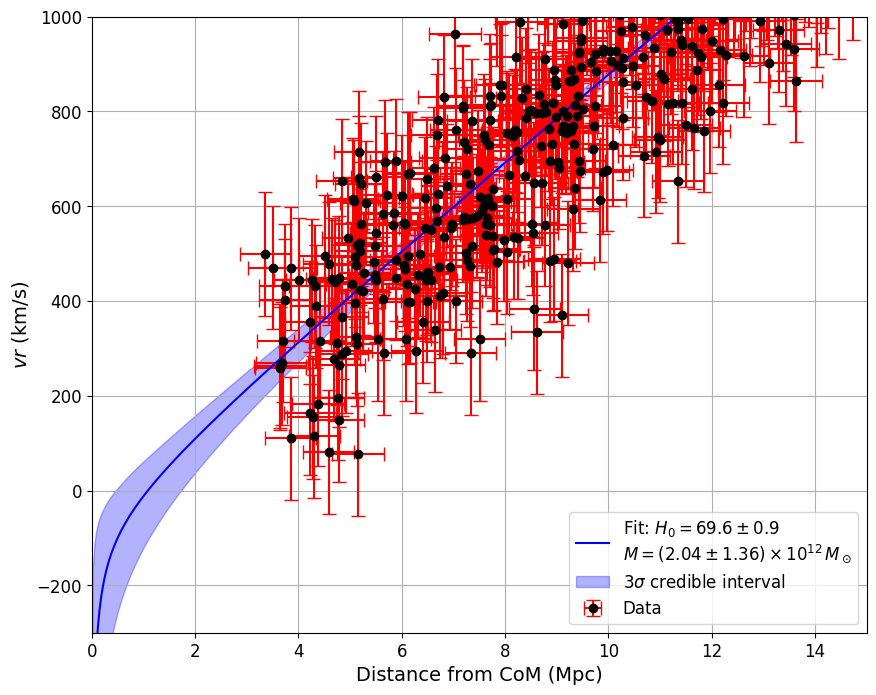

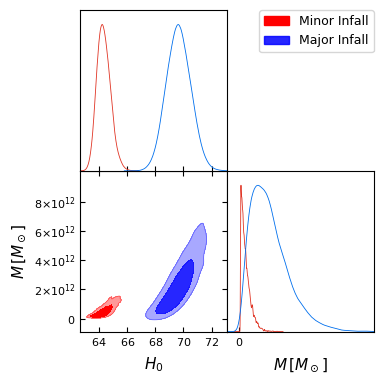

=== Résultats Minor Infall ===
H0 = 64.29 ± 0.49
M = (0.41 ± 0.33) × 10^12 M_☉

=== Résultats Major Infall ===
H0 = 69.64 ± 0.88
M = (2.04 ± 1.36) × 10^12 M_☉


In [12]:
H0_min, H0_sigma_min, M_min, M_sigma_min, samples_min = analyze_velocity_model(df=galaxy_df, mask= mask,row_name= row_name,velocity='minor_infall_velocity',velocity_model=velocity_model_1, xmin=0, xmax=300)
H0_maj, H0_sigma_maj, M_maj, M_sigma_maj, samples_maj = analyze_velocity_model(df=galaxy_df, mask= mask,row_name= row_name,velocity='major_infall_velocity',velocity_model=velocity_model_1, xmin=0, xmax=300)

# Définition des noms et labels cohérents
names = ['H0', 'M']
labels = [r'H_0', r'M \,[M_\odot]']  # Utiliser M_☉ (masse solaire) pour être cohérent

# Créer les objets MCSamples pour les deux analyses
gdsamples_min = MCSamples(samples=samples_min, names=names, labels=labels)
gdsamples_maj = MCSamples(samples=samples_maj, names=names, labels=labels)

# Créer le triangle plot avec les deux distributions
g = plots.get_subplot_plotter()
g.triangle_plot([gdsamples_min, gdsamples_maj], 
                filled=True, 
                legend_labels=['Minor Infall', 'Major Infall'],
                colors=['red', 'blue'])  # Ajouter des couleurs différentes pour mieux distinguer

plt.show()

# Optionnel : afficher les résultats numériques
print("=== Résultats Minor Infall ===")
print(f"H0 = {H0_min:.2f} ± {H0_sigma_min:.2f}")
print(f"M = ({M_min/1e12:.2f} ± {M_sigma_min/1e12:.2f}) × 10^12 M_☉")

print("\n=== Résultats Major Infall ===")
print(f"H0 = {H0_maj:.2f} ± {H0_sigma_maj:.2f}")
print(f"M = ({M_maj/1e12:.2f} ± {M_sigma_maj/1e12:.2f}) × 10^12 M_☉")

In [13]:
file_path = '../../data/generated_data_big.csv'
galaxy_df = pd.read_csv(file_path)
mask = ~galaxy_df['Name'].str.startswith('CoM_')

100%|██████████| 5000/5000 [04:56<00:00, 16.86it/s]


Removed no burn in


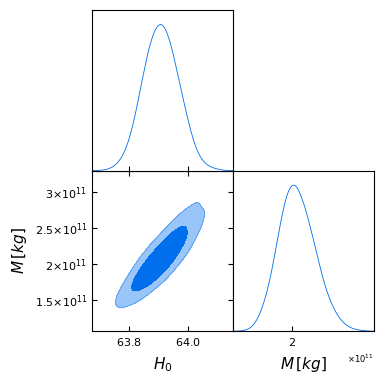

C:\Users\Adrian\AppData\Local\Temp\ipykernel_13684\2484682099.py:11: RuntimeWarning: divide by zero encountered in divide
  sqrt_term = G * M / r
C:\Users\Adrian\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\Adrian\AppData\Local\Temp\ipykernel_13684\3599314567.py:171: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(r_plot, v_median, 'r-', color='blue',label=(rf"Fit: $H_0 = {H0_mcmc:.1f} \pm {H0_uncertainty:.1f}$"+ "\n"+ rf"$M = ({M_mcmc/1e12:.2f} \pm {M_uncertainty/1e12:.2f}) \times 10^{{12}}\, M_\odot$"))
100%|██████████| 5000/5000 [05:14<00:00, 15.89it/s]


Removed no burn in


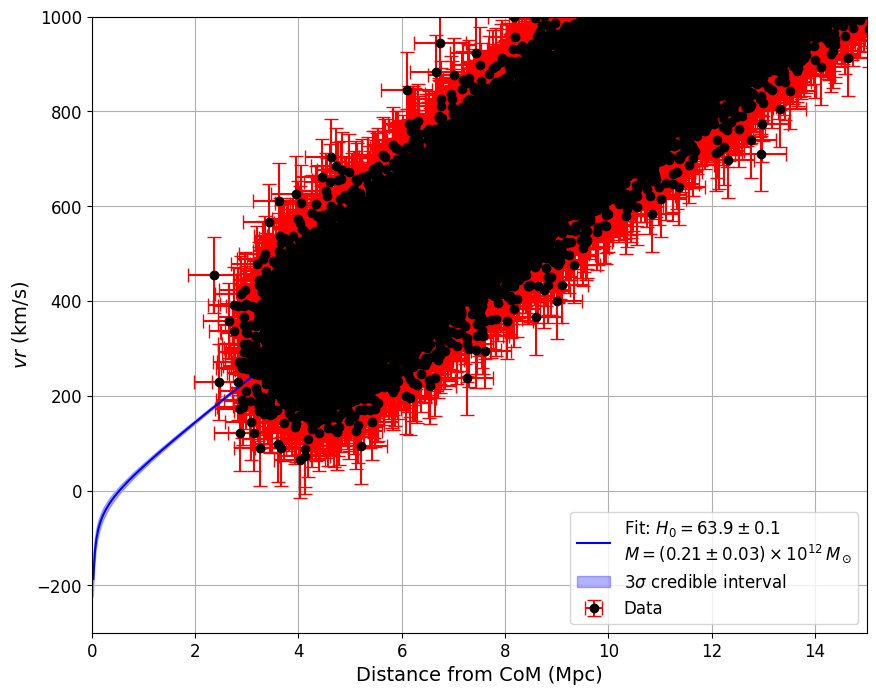

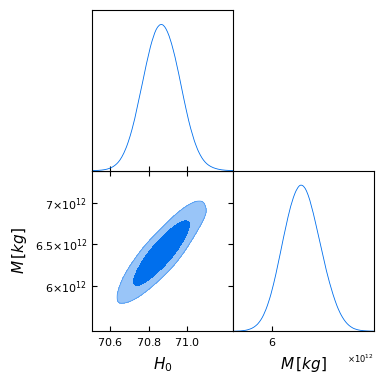

C:\Users\Adrian\AppData\Local\Temp\ipykernel_13684\2484682099.py:11: RuntimeWarning: divide by zero encountered in divide
  sqrt_term = G * M / r
C:\Users\Adrian\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\Adrian\AppData\Local\Temp\ipykernel_13684\3599314567.py:171: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(r_plot, v_median, 'r-', color='blue',label=(rf"Fit: $H_0 = {H0_mcmc:.1f} \pm {H0_uncertainty:.1f}$"+ "\n"+ rf"$M = ({M_mcmc/1e12:.2f} \pm {M_uncertainty/1e12:.2f}) \times 10^{{12}}\, M_\odot$"))


Removed no burn in
Removed no burn in


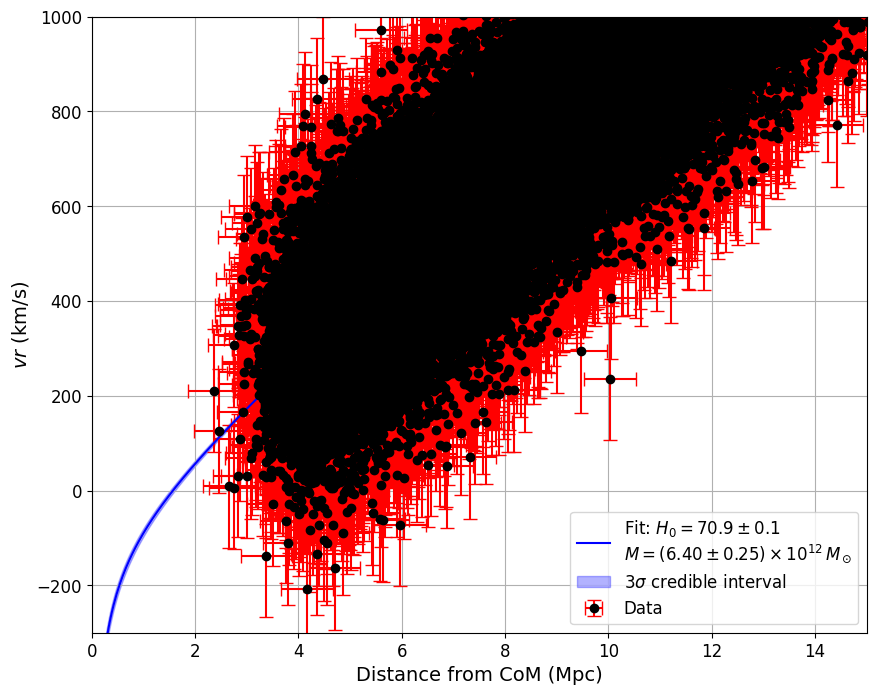

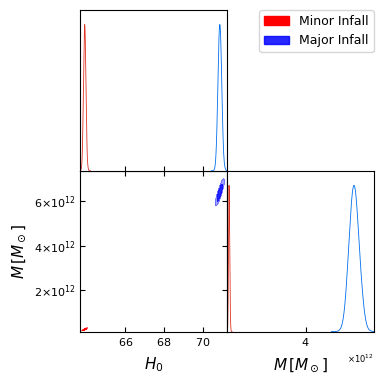

=== Résultats Minor Infall ===
H0 = 63.91 ± 0.06
M = (0.21 ± 0.03) × 10^12 M_☉

=== Résultats Major Infall ===
H0 = 70.87 ± 0.10
M = (6.40 ± 0.25) × 10^12 M_☉


In [14]:
H0_min, H0_sigma_min, M_min, M_sigma_min, samples_min = analyze_velocity_model(df=galaxy_df, mask= mask,row_name= row_name,velocity='minor_infall_velocity',velocity_model=velocity_model_1, xmin=0, xmax=300)
H0_maj, H0_sigma_maj, M_maj, M_sigma_maj, samples_maj = analyze_velocity_model(df=galaxy_df, mask= mask,row_name= row_name,velocity='major_infall_velocity',velocity_model=velocity_model_1, xmin=0, xmax=300)

# Définition des noms et labels cohérents
names = ['H0', 'M']
labels = [r'H_0', r'M \,[M_\odot]']  # Utiliser M_☉ (masse solaire) pour être cohérent

# Créer les objets MCSamples pour les deux analyses
gdsamples_min = MCSamples(samples=samples_min, names=names, labels=labels)
gdsamples_maj = MCSamples(samples=samples_maj, names=names, labels=labels)

# Créer le triangle plot avec les deux distributions
g = plots.get_subplot_plotter()
g.triangle_plot([gdsamples_min, gdsamples_maj], 
                filled=True, 
                legend_labels=['Minor Infall', 'Major Infall'],
                colors=['red', 'blue'])  # Ajouter des couleurs différentes pour mieux distinguer

plt.show()

# Optionnel : afficher les résultats numériques
print("=== Résultats Minor Infall ===")
print(f"H0 = {H0_min:.2f} ± {H0_sigma_min:.2f}")
print(f"M = ({M_min/1e12:.2f} ± {M_sigma_min/1e12:.2f}) × 10^12 M_☉")

print("\n=== Résultats Major Infall ===")
print(f"H0 = {H0_maj:.2f} ± {H0_sigma_maj:.2f}")
print(f"M = ({M_maj/1e12:.2f} ± {M_sigma_maj/1e12:.2f}) × 10^12 M_☉")